# Experimento 6: BioLinkBERT-base para Relation Extraction

**Objetivo:** Comparar BioLinkBERT-base con PubMedBERT usando exactamente la misma configuracion que el Experimento 1A.

**Hipotesis:** BioLinkBERT fue entrenado no solo con texto biomedico sino tambien modelando los **enlaces** entre documentos de PubMed (como si supiera que articulos citan a otros). Esto le da una comprension mas rica de las conexiones entre conceptos, lo que deberia ser especialmente util para relation extraction.

**Diferencia con 1A:** Solo cambia el backbone. Todo lo demas (datos, hiperparametros, arquitectura) es identico para que la comparacion sea justa -- ver seccion 12 para la comparacion 1:1 real.

**Resultado (confirmado, ver seccion 12):** BioLinkBERT-base **supera a PubMedBERT** en los tres escenarios evaluados (curado, ciego argmax, ciego con threshold), y esa ventaja se mantiene estable en los 19 thresholds del barrido completo -- no depende de un punto de corte concreto.

**Referencia de contexto:**
- Baseline (bert-multilingual): Macro F1 = 0.6944 curado / 0.3435 segun el README oficial de NEREL-BIO en ciego (este ultimo no se ha logrado reproducir en este repo -- ver seccion 10)
- PubMedBERT (1A, **15 epochs, run real**): Macro F1 = **0.7777** curado -- esta es la cifra que se usa en toda comparacion (seccion 12); la de "0.7754 / 10ep" que se citaba aqui antes viene de un run cuyo checkpoint nunca se recupero y no es la que esta guardada en `outputs/`
- Exp2/Exp3 (typed markers, neg_ratio 1:1): 0.8078 / 0.8430 -- numeros heredados de notebooks/experimentos que no tienen `outputs/` en este repo, no verificables localmente

**Modelo a probar:** `michiyasunaga/BioLinkBERT-base`

**Referencia bibliografica:** Sanger & Leser, BMC Bioinformatics 2025 — BioLinkBERT-large es el mejor modelo en todos los datasets de RE biomedica evaluados.

## 1. Setup e Instalacion

In [1]:
# Ejecucion en servidor remoto (zape), entorno conda "tfg".
# Descomenta la primera vez que uses este entorno (instala dependencias):
# !pip install git+https://github.com/thunlp/OpenNRE.git
# !pip install torch transformers nltk pandas scikit-learn matplotlib seaborn tqdm

# NOTA: al reiniciar el kernel es normal ver un banner de /etc/profile diciendo
# "All Hugging Face models are cached in /opt/huggingface" -- es ruido informativo
# del login shell del servidor, no significa que el override de abajo no vaya a
# aplicarse. Basta con ejecutar esta celda ANTES de cualquier import de
# opennre/transformers/huggingface_hub para que quede sobrescrito el resto de la sesion.

# La cache compartida /opt/huggingface no es escribible para este usuario
# (no pertenece al grupo "users" que la posee). El servidor ya trae HF_HOME
# / HF_HUB_CACHE definidas globalmente apuntando ahi, asi que hace falta
# SOBRESCRIBIRLAS (no basta con setdefault) para que apunten a una carpeta
# propia del home donde si podemos descargar modelos nuevos.
import os
HF_CACHE_DIR = os.path.expanduser("~/hf_cache")
os.environ["HF_HOME"] = HF_CACHE_DIR
os.environ["HF_HUB_CACHE"] = os.path.join(HF_CACHE_DIR, "hub")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(HF_CACHE_DIR, "hub")
os.makedirs(os.environ["HF_HUB_CACHE"], exist_ok=True)
print(f"HF_HOME: {os.environ['HF_HOME']}")
print(f"HF_HUB_CACHE: {os.environ['HF_HUB_CACHE']}")

# Verificacion: confirma que huggingface_hub (no solo os.environ) resuelve la
# cache al directorio propio, y que es escribible. Si esto falla, algo importo
# huggingface_hub/transformers ANTES de esta celda en la sesion actual.
import huggingface_hub.constants as hfc
assert hfc.HF_HUB_CACHE == os.environ["HF_HUB_CACHE"], (
    f"huggingface_hub resolvio {hfc.HF_HUB_CACHE!r}, se esperaba {os.environ['HF_HUB_CACHE']!r}. "
    "Reinicia el kernel y ejecuta esta celda primero, antes de cualquier import de HF/opennre."
)
test_file = os.path.join(os.environ["HF_HUB_CACHE"], ".write_test")
with open(test_file, "w") as f:
    f.write("ok")
os.remove(test_file)
print("Cache HF verificada y escribible.")

# Aplica los parches de compatibilidad de OpenNRE
# (UTF-8 en lectura de datos, AdamW de torch en vez de transformers, num_workers=0)
!python ../baseline/patch_opennre.py

HF_HOME: /home/lucia.esperon/hf_cache
HF_HUB_CACHE: /home/lucia.esperon/hf_cache/hub
Cache HF verificada y escribible.
Already patched, nothing to do.


In [2]:
import json
import importlib
import time
import logging
import os
from collections import Counter
from pathlib import Path

import nltk
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import opennre

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

/home/lucia.esperon/miniconda3/envs/tfg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.6.0+cu124
CUDA disponible: True
GPU: NVIDIA GeForce RTX 2080 Ti
VRAM: 11.5 GB


## 2. Configuracion del Experimento

La unica diferencia con Exp1 es `MODEL_NAME`. Todo lo demas es identico.

In [3]:
# ============================================================
# CONFIGURACION - EXPERIMENTO 6: BioLinkBERT-base
# ============================================================

# *** UNICO CAMBIO RESPECTO A EXP1 ***
MODEL_NAME = "michiyasunaga/BioLinkBERT-base"
EXPERIMENT_NAME = "biolinkbert_base"

# Por que BioLinkBERT?
# - Entrenado con PubMed + enlaces entre documentos (document linking)
# - Entiende conexiones entre conceptos biomedicos mejor que PubMedBERT
# - Sanger & Leser 2025 (BMC Bioinformatics): mejor modelo en 5/5 datasets de RE biomedica
# - La version base tiene ~110M params (igual que PubMedBERT), sin problemas de VRAM en T4

# HIPERPARAMETROS (identicos a Exp1, 15 epochs para comparacion justa)
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 15
WARMUP_STEPS = 300
SEED = 42
NEG_RATIO = 3  # igual que Exp1, datos originales sin modificar

# Paths LOCALES (ejecucion en local, no Kaggle)
DATA_DIR = Path("../data/english")
TRAIN_DATA = DATA_DIR / "eng_train.txt"
DEV_DATA = DATA_DIR / "eng_dev.txt"
REL2ID_PATH = DATA_DIR / "rel2id.json"

# Outputs: carpeta propia de este experimento
OUTPUT_DIR = Path("../outputs/1B-biolinkbert")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"
PRED_PATH = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME}.tsv"

RELATION_TYPES = [
    "ABBREVIATION", "ALTERNATIVE_NAME", "SUBCLASS_OF", "PART_OF",
    "TREATED_USING", "ORIGINS_FROM", "TO_DETECT_OR_STUDY", "AFFECTS",
    "HAS_CAUSE", "APPLIED_TO", "USED_IN", "ASSOCIATED_WITH",
    "PHYSIOLOGY_OF", "FINDING_OF",
    "no_relation",
]

with open(REL2ID_PATH) as f:
    rel2id = json.load(f)

print(f"Experimento: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Datos: {DATA_DIR}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Clases: {len(RELATION_TYPES)} (14 relaciones + no_relation)")

Experimento: biolinkbert_base
Modelo: michiyasunaga/BioLinkBERT-base
Datos: ../data/english
Checkpoint: ../outputs/1B-biolinkbert/eng_biolinkbert_base.pth.tar
Clases: 15 (14 relaciones + no_relation)


## 3. Verificar Datos

In [4]:
assert TRAIN_DATA.exists(), f"No se encuentra {TRAIN_DATA}"
assert DEV_DATA.exists(), f"No se encuentra {DEV_DATA}"
assert REL2ID_PATH.exists(), f"No se encuentra {REL2ID_PATH}"

with open(TRAIN_DATA) as f:
    n_train = sum(1 for line in f if line.strip())
with open(DEV_DATA) as f:
    n_dev = sum(1 for line in f if line.strip())

print(f"Train: {n_train} instancias")
print(f"Dev:   {n_dev} instancias")
print(f"Clases: {len(rel2id)}")

# Distribucion de relaciones
train_instances = []
with open(TRAIN_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            train_instances.append(json.loads(line))

rel_counts = Counter(inst["relation"] for inst in train_instances)
print(f"\nDistribucion en train:")
for rel, count in rel_counts.most_common():
    print(f"  {rel:<25} {count:>6} ({100*count/len(train_instances):5.1f}%)")

Train: 12739 instancias
Dev:   2967 instancias
Clases: 15

Distribucion en train:
  no_relation                 9546 ( 74.9%)
  SUBCLASS_OF                  743 (  5.8%)
  HAS_CAUSE                    579 (  4.5%)
  AFFECTS                      362 (  2.8%)
  ASSOCIATED_WITH              325 (  2.6%)
  PART_OF                      204 (  1.6%)
  TO_DETECT_OR_STUDY           164 (  1.3%)
  PHYSIOLOGY_OF                150 (  1.2%)
  FINDING_OF                   121 (  0.9%)
  ORIGINS_FROM                 120 (  0.9%)
  TREATED_USING                101 (  0.8%)
  ABBREVIATION                  97 (  0.8%)
  ALTERNATIVE_NAME              95 (  0.7%)
  USED_IN                       89 (  0.7%)
  APPLIED_TO                    43 (  0.3%)


## 4. Parchear OpenNRE y Entrenar

Mismos parches que en Exp1: AdamW de torch en vez de transformers, y `dataset.eval()` extendido para calcular macro_f1 y seleccionar el mejor checkpoint por esa métrica (no por micro_f1).

In [5]:
# El parche de AdamW (transformers.AdamW -> torch.optim.AdamW) ya lo aplica
# ../baseline/patch_opennre.py (celda de setup). Antes se repetia aqui a
# mano, igual que en 1A; se quito por duplicado.
print("AdamW ya parcheado por baseline/patch_opennre.py.")

OpenNRE parcheado.


In [6]:
# ============================================================
# Parchear OpenNRE: dataset.eval() tambien calcula macro_f1
# Logica compartida con 1A, centralizada en
# baseline/patch_opennre.py (add_macro_f1_metric) en vez de duplicada
# a mano en cada notebook.
# ============================================================
import sys
sys.path.insert(0, "../baseline")
from patch_opennre import add_macro_f1_metric

add_macro_f1_metric()
print("dataset.eval() parcheado: ahora devuelve tambien 'macro_f1'.")

dataset.eval() parcheado: ahora devuelve tambien 'macro_f1'.


In [7]:
print("=" * 60)
print(f"ENTRENAMIENTO: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Datos: originales (neg_ratio=3:1, sin typed markers)")
print(f"Epochs: {EPOCHS}")
print("=" * 60)

encoder = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model = opennre.model.SoftmaxNN(
    sentence_encoder=encoder,
    num_class=len(rel2id),
    rel2id=rel2id,
)

framework = opennre.framework.SentenceRE(
    model=model,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH),
    batch_size=BATCH_SIZE,
    max_epoch=EPOCHS,
    lr=LEARNING_RATE,
    opt="adamw",
    warmup_step=WARMUP_STEPS,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nParametros del modelo: {n_params:,}")
print(f"Listo para entrenar.")

2026-07-23 07:43:55,766 - root - INFO - Loading BERT pre-trained checkpoint.


ENTRENAMIENTO: biolinkbert_base
Modelo: michiyasunaga/BioLinkBERT-base
Datos: originales (neg_ratio=3:1, sin typed markers)
Epochs: 15


2026-07-23 07:43:56,579 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25991.55it/s]
2026-07-23 07:43:58,788 - root - INFO - Loaded sentence RE dataset ../data/english/eng_train.txt with 12739 lines and 15 relations.
2026-07-23 07:43:58,885 - root - INFO - Loaded sentence RE dataset ../data/english/eng_dev.txt with 2967 lines and 15 relations.
2026-07-23 07:43:58,983 - root - INFO - Loaded sentence RE dataset ../data/english/eng_dev.txt with 2967 lines and 15 relations.



Parametros del modelo: 110,616,591
Listo para entrenar.


In [8]:
# ============================================================
# ENTRENAR con historial por epoch (loss/acc train + P/R/F1 val)
# Reimplementa el bucle interno de SentenceRE.train_model (que no expone
# metricas por epoch) para poder guardar una curva de entreno y validar
# en cada epoch. Guarda el mejor checkpoint segun METRIC (macro_f1).
# ============================================================
from opennre.framework.utils import AverageMeter
from tqdm import tqdm

METRIC = "macro_f1"

def train_with_history(fw, max_epoch, metric="macro_f1"):
    history = []
    best_metric = 0
    for epoch in range(max_epoch):
        fw.train()
        avg_loss = AverageMeter()
        avg_acc = AverageMeter()
        t = tqdm(fw.train_loader, desc=f"Epoch {epoch}")
        for data in t:
            if torch.cuda.is_available():
                for i in range(len(data)):
                    try:
                        data[i] = data[i].cuda()
                    except Exception:
                        pass
            label = data[0]
            args = data[1:]
            logits = fw.parallel_model(*args)
            loss = fw.criterion(logits, label)
            _, pred = logits.max(-1)
            acc = float((pred == label).long().sum()) / label.size(0)
            avg_loss.update(loss.item(), 1)
            avg_acc.update(acc, 1)
            t.set_postfix(loss=avg_loss.avg, acc=avg_acc.avg)
            loss.backward()
            fw.optimizer.step()
            if fw.scheduler is not None:
                fw.scheduler.step()
            fw.optimizer.zero_grad()

        # Validacion al final de cada epoch (dataset.eval ya devuelve macro_f1, celda parcheada arriba)
        val_result = fw.eval_model(fw.val_loader)

        record = {
            "epoch": epoch,
            "train_loss": avg_loss.avg,
            "train_acc": avg_acc.avg,
            "val_acc": val_result["acc"],
            "val_micro_p": val_result["micro_p"],
            "val_micro_r": val_result["micro_r"],
            "val_micro_f1": val_result["micro_f1"],
            "val_macro_f1": val_result["macro_f1"],
        }
        history.append(record)
        print(f"Epoch {epoch}: train_loss={record['train_loss']:.4f} train_acc={record['train_acc']:.4f} "
              f"val_micro_f1={record['val_micro_f1']:.4f} val_macro_f1={record['val_macro_f1']:.4f}")

        if val_result[metric] > best_metric:
            print(f"  -> nuevo mejor {metric}={val_result[metric]:.4f}, guardando checkpoint")
            folder_path = "/".join(fw.ckpt.split("/")[:-1])
            if folder_path and not os.path.exists(folder_path):
                os.makedirs(folder_path, exist_ok=True)
            torch.save({"state_dict": fw.model.state_dict()}, fw.ckpt)
            best_metric = val_result[metric]

    print(f"\nMejor {metric} en val: {best_metric:.4f}")
    return history

# ENTRENAR - Esta celda tarda ~60-90 min con GPU (15 epochs)
start_time = time.time()

history = train_with_history(framework, EPOCHS, metric=METRIC)

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH}")

HISTORY_PATH = OUTPUT_DIR / f"history_{EXPERIMENT_NAME}.json"
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Historial guardado en: {HISTORY_PATH}")

100%|██████████| 186/186 [00:10<00:00, 17.45it/s, acc=0.622]
2026-07-23 07:46:15,158 - root - INFO - Evaluation result: {'acc': 0.621840242669363, 'micro_p': 0.7388866639967961, 'micro_r': 0.621840242669363, 'micro_f1': 0.6753294289897511}.


Epoch 0: train_loss=0.8431 train_acc=0.7753 val_micro_f1=0.6753 val_macro_f1=0.4845
  -> nuevo mejor macro_f1=0.4845, guardando checkpoint


100%|██████████| 186/186 [00:10<00:00, 17.17it/s, acc=0.691]
2026-07-23 07:48:35,239 - root - INFO - Evaluation result: {'acc': 0.6909336029659588, 'micro_p': 0.8464079273327828, 'micro_r': 0.6909336029659588, 'micro_f1': 0.7608090554833921}.


Epoch 1: train_loss=0.3019 train_acc=0.9181 val_micro_f1=0.7608 val_macro_f1=0.6441
  -> nuevo mejor macro_f1=0.6441, guardando checkpoint


100%|██████████| 186/186 [00:10<00:00, 16.96it/s, acc=0.76] 
2026-07-23 07:50:58,406 - root - INFO - Evaluation result: {'acc': 0.7600269632625548, 'micro_p': 0.8683095879861379, 'micro_r': 0.7600269632625548, 'micro_f1': 0.810567936736161}.


...

Epoch 12: train_loss=0.0073 train_acc=0.9978 val_micro_f1=0.8200 val_macro_f1=0.7649


100%|██████████| 186/186 [00:11<00:00, 16.46it/s, acc=0.776]
2026-07-23 08:17:32,471 - root - INFO - Evaluation result: {'acc': 0.7758678800134816, 'micro_p': 0.8686792452830189, 'micro_r': 0.7758678800134816, 'micro_f1': 0.8196546199038632}.


Epoch 13: train_loss=0.0056 train_acc=0.9984 val_micro_f1=0.8197 val_macro_f1=0.7709


100%|██████████| 186/186 [00:11<00:00, 16.65it/s, acc=0.785]
2026-07-23 08:19:56,496 - root - INFO - Evaluation result: {'acc': 0.7846309403437816, 'micro_p': 0.8680089485458613, 'micro_r': 0.7846309403437816, 'micro_f1': 0.8242166755177907}.


Epoch 14: train_loss=0.0041 train_acc=0.9989 val_micro_f1=0.8242 val_macro_f1=0.7785

Mejor macro_f1 en val: 0.7835

Entrenamiento completado en 36.0 minutos
Mejor checkpoint guardado en: ../outputs/1B-biolinkbert/eng_biolinkbert_base.pth.tar
Historial guardado en: ../outputs/1B-biolinkbert/history_biolinkbert_base.json


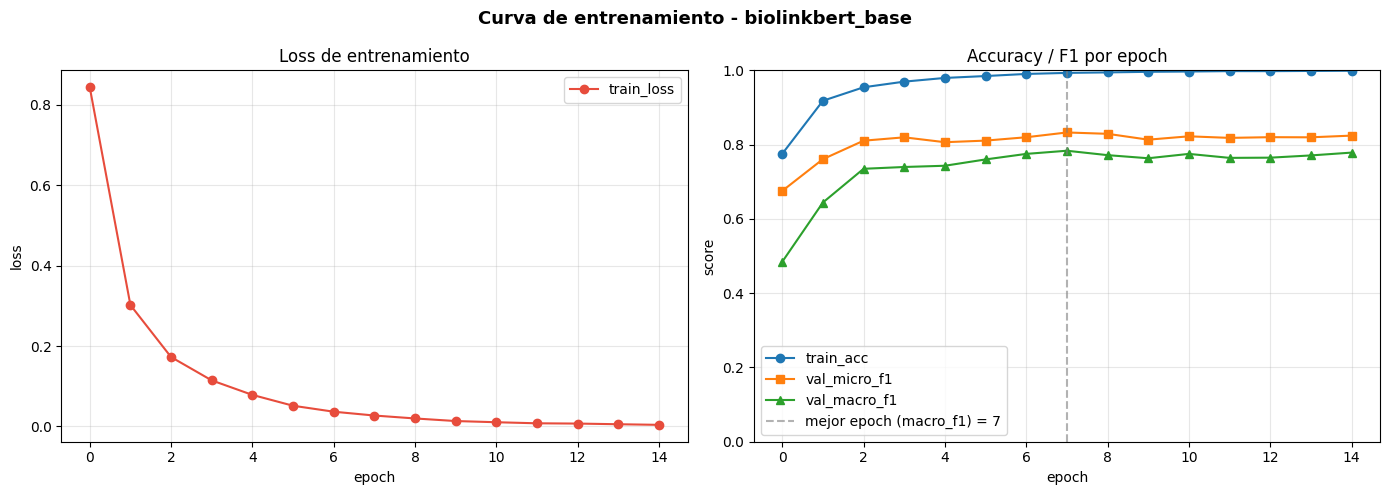

Grafica guardada en: ../outputs/1B-biolinkbert/curva_entreno_biolinkbert_base.png


In [9]:
# ============================================================
# GRAFICA DE LA CURVA DE ENTRENO (loss + F1 por epoch)
# ============================================================
epochs_x = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Curva de entrenamiento - {EXPERIMENT_NAME}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(epochs_x, [h["train_loss"] for h in history], marker="o", color="#e74c3c", label="train_loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("Loss de entrenamiento")
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(epochs_x, [h["train_acc"] for h in history], marker="o", label="train_acc")
ax2.plot(epochs_x, [h["val_micro_f1"] for h in history], marker="s", label="val_micro_f1")
ax2.plot(epochs_x, [h["val_macro_f1"] for h in history], marker="^", label="val_macro_f1")
best_epoch = max(history, key=lambda h: h["val_macro_f1"])["epoch"]
ax2.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"mejor epoch (macro_f1) = {best_epoch}")
ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.set_title("Accuracy / F1 por epoch")
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"curva_entreno_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Grafica guardada en: {OUTPUT_DIR / f'curva_entreno_{EXPERIMENT_NAME}.png'}")

In [10]:
# ============================================================
# COMPARACION: que epoch habria elegido micro_f1 vs. macro_f1
# (justificacion para la memoria del TFG de por que seleccionar por macro_f1)
# ============================================================
best_by_micro = max(history, key=lambda h: h["val_micro_f1"])
best_by_macro = max(history, key=lambda h: h["val_macro_f1"])

print(f"{'Criterio de seleccion':<30}{'Epoch':>8}{'val_micro_f1':>16}{'val_macro_f1':>16}")
print("-" * 70)
print(f"{'Si se seleccionara por micro_f1':<30}{best_by_micro['epoch']:>8}{best_by_micro['val_micro_f1']:>16.4f}{best_by_micro['val_macro_f1']:>16.4f}")
print(f"{'Seleccionado por macro_f1 (usado)':<30}{best_by_macro['epoch']:>8}{best_by_macro['val_micro_f1']:>16.4f}{best_by_macro['val_macro_f1']:>16.4f}")
print("-" * 70)

if best_by_micro["epoch"] == best_by_macro["epoch"]:
    print("\nEn este run coinciden en la misma epoch: no hay divergencia que mostrar esta vez.")
else:
    diff = best_by_macro["val_macro_f1"] - best_by_micro["val_macro_f1"]
    print(f"\nDivergencia real: seleccionar por micro_f1 habria dado macro_f1={best_by_micro['val_macro_f1']:.4f} "
          f"(epoch {best_by_micro['epoch']}), frente a macro_f1={best_by_macro['val_macro_f1']:.4f} "
          f"(epoch {best_by_macro['epoch']}) seleccionando por macro_f1 -> diferencia de {diff:+.4f}.")

json.dump({
    "best_by_micro_f1": best_by_micro,
    "best_by_macro_f1": best_by_macro,
}, open(OUTPUT_DIR / f"comparacion_micro_vs_macro_{EXPERIMENT_NAME}.json", "w"), indent=2)
print(f"\nguardado: comparacion_micro_vs_macro_{EXPERIMENT_NAME}.json")

Criterio de seleccion            Epoch    val_micro_f1    val_macro_f1
----------------------------------------------------------------------
Si se seleccionara por micro_f1       7          0.8327          0.7835
Seleccionado por macro_f1 (usado)       7          0.8327          0.7835
----------------------------------------------------------------------

En este run coinciden en la misma epoch: no hay divergencia que mostrar esta vez.

guardado: comparacion_micro_vs_macro_biolinkbert_base.json


## 5. Prediccion en Dev

In [11]:
# Cargar mejor checkpoint
encoder_pred = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
model_pred.load_state_dict(ckpt["state_dict"])

if torch.cuda.is_available():
    model_pred = model_pred.cuda()
model_pred.eval()

print(f"Modelo cargado desde: {CKPT_PATH}")

2026-07-23 08:19:57,038 - root - INFO - Loading BERT pre-trained checkpoint.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 26650.48it/s]


Modelo cargado desde: ../outputs/1B-biolinkbert/eng_biolinkbert_base.pth.tar


In [12]:
# Predecir en dev
dev_instances = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances.append(json.loads(line))

print(f"Prediciendo {len(dev_instances)} instancias...")

rows = []
for inst in dev_instances:
    pred_rel, score = model_pred.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones (formato CodaBench)
pred_df = pd.DataFrame(rows)
pred_export = pred_df[["document_id", "relation", "head_text", "head_span",
                        "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export = pred_export[pred_export["relation"] != "no_relation"]
pred_export.to_csv(PRED_PATH, sep="\t", index=False)

n_filtered = len(pred_df) - len(pred_export)
print(f"Filtradas {n_filtered} predicciones no_relation")
print(f"Predicciones guardadas en: {PRED_PATH}")

Prediciendo 2967 instancias...
Filtradas 196 predicciones no_relation
Predicciones guardadas en: ../outputs/1B-biolinkbert/eng_pred_biolinkbert_base.tsv


## 6. Evaluacion y Comparacion

In [13]:
# Calcular metricas por relacion
all_relations = sorted(rel2id.keys())

gold_labels = [inst["relation"] for inst in dev_instances]
pred_labels = [row["relation"] for row in rows]

correct = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
total = len(gold_labels)
accuracy = correct / total

gold_counts = Counter(gold_labels)
pred_counts = Counter(pred_labels)
tp_counts = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g == p:
        tp_counts[g] += 1

results = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores = []
for rel in all_relations:
    tp = tp_counts.get(rel, 0)
    pred_total = pred_counts.get(rel, 0)
    gold_total = gold_counts.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores.append(f1)
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

print("-" * 60)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

# PubMedBERT: cargado del resultado real de 1A (15 epochs), no hardcodeado -- la
# version anterior de esta celda usaba "0.7754/10ep", numero de un run cuyo
# checkpoint nunca se recupero (ver cabecera del notebook y seccion 12).
with open("../outputs/1A-pubmedbert/results_pubmedbert.json") as f:
    _pubmedbert_1a = json.load(f)["results"]["macro_f1"]

# Tabla comparativa completa
print(f"\n{'='*65}")
print(f"COMPARACION DE TODOS LOS EXPERIMENTOS")
print(f"{'='*65}")
print(f"{'Experimento':<45} {'Macro F1':>10} {'Diff':>10}")
print(f"{'-'*65}")
print(f"{'Baseline (bert-multi, 10ep)':<45} {'0.6944':>10} {'---':>10}")
print(f"{'Exp1A: PubMedBERT (15ep)':<45} {_pubmedbert_1a:>10.4f} {_pubmedbert_1a - 0.6944:>+10.4f}")
print(f"{'Exp2: PubMedBERT + typed markers (15ep)':<45} {'0.8078':>10} {'+0.1134':>10}")
print(f"{'Exp3: PubMedBERT + typed + neg 1:1 (15ep)':<45} {'0.8430':>10} {'+0.1486':>10}")
print(f"{'Exp6: BioLinkBERT-base (' + str(EPOCHS) + 'ep)':<45} {macro_f1:>10.4f} {macro_f1 - 0.6944:>+10.4f}")
print(f"{'='*65}")
print(f"\nBioLinkBERT-base vs PubMedBERT (1A): {macro_f1 - _pubmedbert_1a:+.4f}")

Relacion                         P        R       F1  Soporte
------------------------------------------------------------
ABBREVIATION                0.9286   0.8784   0.9028       74
AFFECTS                     0.9185   0.8601   0.8883      393
ALTERNATIVE_NAME            0.7400   0.3776   0.5000       98
APPLIED_TO                  0.5455   0.4444   0.4898       54
ASSOCIATED_WITH             0.8485   0.7210   0.7796      233
FINDING_OF                  0.5946   0.7952   0.6804       83
HAS_CAUSE                   0.8429   0.8152   0.8288      487
ORIGINS_FROM                0.8831   0.8608   0.8718       79
PART_OF                     0.8986   0.7500   0.8176      248
PHYSIOLOGY_OF               0.9459   0.7865   0.8589      178
SUBCLASS_OF                 0.8838   0.8943   0.8890      757
TO_DETECT_OR_STUDY          0.8214   0.7931   0.8070      116
TREATED_USING               0.9730   0.8182   0.8889       88
USED_IN                     0.7867   0.7468   0.7662       79
---------

## 7. Analisis de Errores

In [14]:
# Errores mas comunes
confusion_pairs = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g != p:
        confusion_pairs[(g, p)] += 1

total_errors = sum(confusion_pairs.values())
print(f"Total errores: {total_errors} / {total} ({100*total_errors/total:.1f}%)")

# Confusiones de PubMedBERT (1A): recalculadas corriendo el checkpoint real
# (outputs/1A-pubmedbert/eng_pubmedbert.pth.tar) contra el dev real -- la version
# anterior de esta celda tenia un dict "exp1_errors" hardcodeado que no coincidia
# con ningun archivo guardado en outputs/1A-pubmedbert/ (no habia error_analysis
# ahi). Si no existe el archivo recalculado, esta celda no falla: solo omite esa
# comparacion y muestra unicamente las confusiones de BioLinkBERT.
_exp1a_errors_path = Path("../outputs/1A-pubmedbert/error_analysis_pubmedbert.json")
if _exp1a_errors_path.exists():
    with open(_exp1a_errors_path) as f:
        _exp1a_error_data = json.load(f)
    exp1_errors = {(c["gold"], c["pred"]): c["count"] for c in _exp1a_error_data["top_confusions"]}

    print(f"\nComparacion con Exp1A (PubMedBERT, checkpoint real) en las confusiones clave:")
    print(f"{'Confusion':<50} {'Exp1A':>6} {'Exp6':>6} {'Cambio':>8}")
    print("-" * 75)
    top_exp1a = sorted(exp1_errors.items(), key=lambda x: -x[1])[:5]
    for (g, p), prev_count in top_exp1a:
        curr_count = confusion_pairs.get((g, p), 0)
        diff = curr_count - prev_count
        symbol = "✓ mejora" if diff < 0 else "✗ peor" if diff > 0 else "= igual"
        print(f"{g} -> {p:<30} {prev_count:>6} {curr_count:>6} {diff:>+8} ({symbol})")
else:
    print("\n(outputs/1A-pubmedbert/error_analysis_pubmedbert.json no existe -- "
          "omitiendo comparacion de confusiones con PubMedBERT)")

print(f"\nTop 10 confusiones actuales (BioLinkBERT):")
print(f"{'Real':<25} {'Predicho':<25} {'Count':>6}")
print("-" * 60)
for (g, p), count in confusion_pairs.most_common(10):
    print(f"{g:<25} {p:<25} {count:>6}")

Total errores: 578 / 2967 (19.5%)

Comparacion con Exp1 (PubMedBERT) en las confusiones clave:
Confusion                                            Exp1   Exp6   Cambio
---------------------------------------------------------------------------
ALTERNATIVE_NAME -> no_relation                        53     38      -15 (✓ mejora)
HAS_CAUSE -> no_relation                        53     40      -13 (✓ mejora)
PART_OF -> SUBCLASS_OF                        51     51       +0 (= igual)
AFFECTS -> no_relation                        36     27       -9 (✓ mejora)
SUBCLASS_OF -> HAS_CAUSE                          26     25       -1 (✓ mejora)

Top 10 confusiones actuales (BioLinkBERT):
Real                      Predicho                   Count
------------------------------------------------------------
PART_OF                   SUBCLASS_OF                   51
HAS_CAUSE                 no_relation                   40
ALTERNATIVE_NAME          no_relation                   38
ASSOCIATED_WITH     

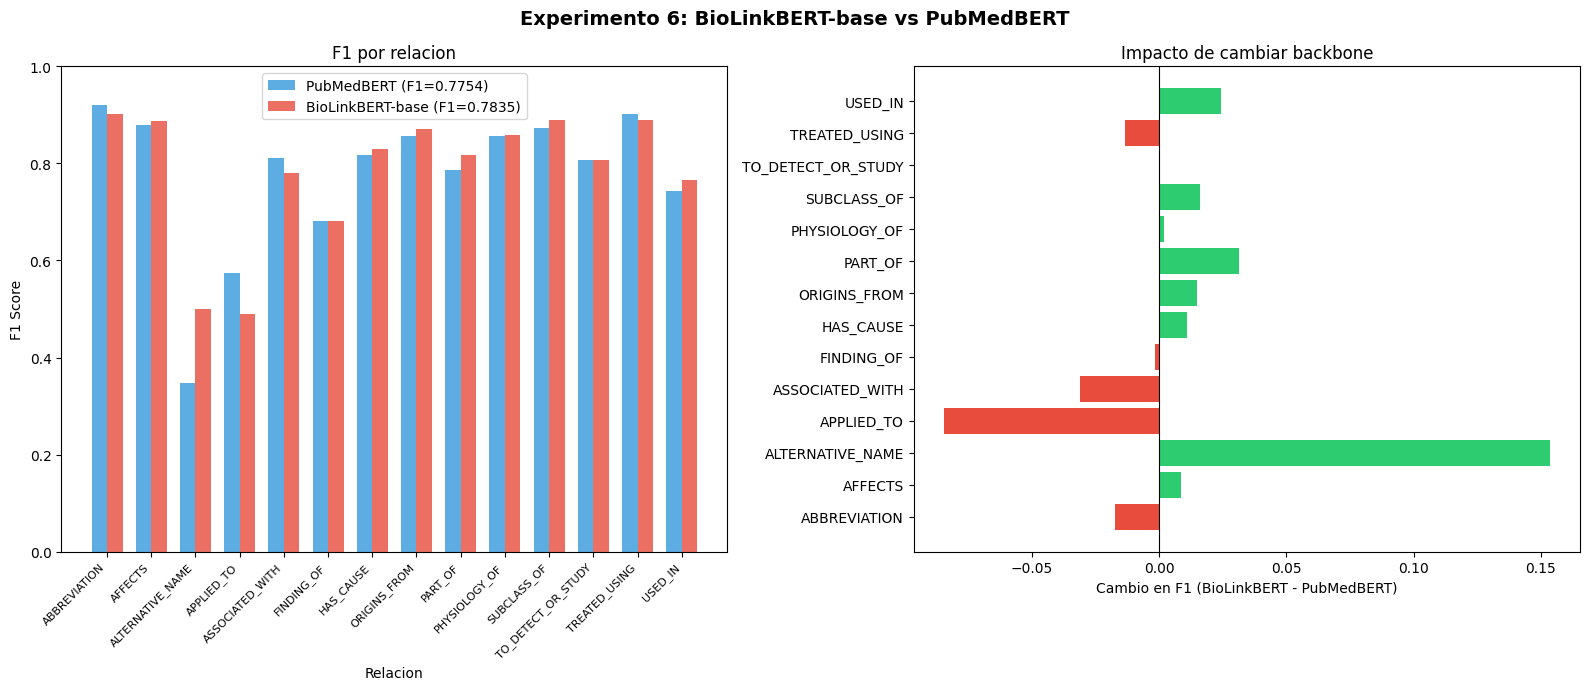

In [15]:
# Comparacion visual: BioLinkBERT vs PubMedBERT por relacion
# F1 de PubMedBERT: cargado del resultado real de 1A (15 epochs, verificado en
# outputs/1A-pubmedbert/), no hardcodeado -- la version anterior de esta celda
# usaba un dict fijo etiquetado "Exp1 PubMedBERT 10ep" que resulto venir de un
# run cuyo checkpoint nunca se recupero (ver seccion 12 y cabecera del notebook).
with open("../outputs/1A-pubmedbert/results_pubmedbert.json") as f:
    _res_1a_plot = json.load(f)
pubmedbert_f1 = {rel: m["f1"] for rel, m in _res_1a_plot["results"]["per_relation"].items() if rel != "no_relation"}
pubmedbert_macro_f1 = _res_1a_plot["results"]["macro_f1"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Experimento 6: BioLinkBERT-base vs PubMedBERT", fontsize=14, fontweight="bold")

rels_plot = [r for r in all_relations if results.get(r, {}).get("support", 0) > 0]
f1_pubmed = [pubmedbert_f1.get(r, 0) for r in rels_plot]
f1_biolink = [results[r]["f1"] for r in rels_plot]

# Barras comparativas
x = np.arange(len(rels_plot))
width = 0.35
axes[0].bar(x - width/2, f1_pubmed, width,
            label=f'PubMedBERT (F1={pubmedbert_macro_f1:.4f})', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, f1_biolink, width,
            label=f'BioLinkBERT-base (F1={macro_f1:.4f})', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Relacion')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 por relacion')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rels_plot, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Diferencia por relacion
diffs = [f1_biolink[i] - f1_pubmed[i] for i in range(len(rels_plot))]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
axes[1].barh(rels_plot, diffs, color=colors)
axes[1].set_xlabel('Cambio en F1 (BioLinkBERT - PubMedBERT)')
axes[1].set_title('Impacto de cambiar backbone')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"comparacion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

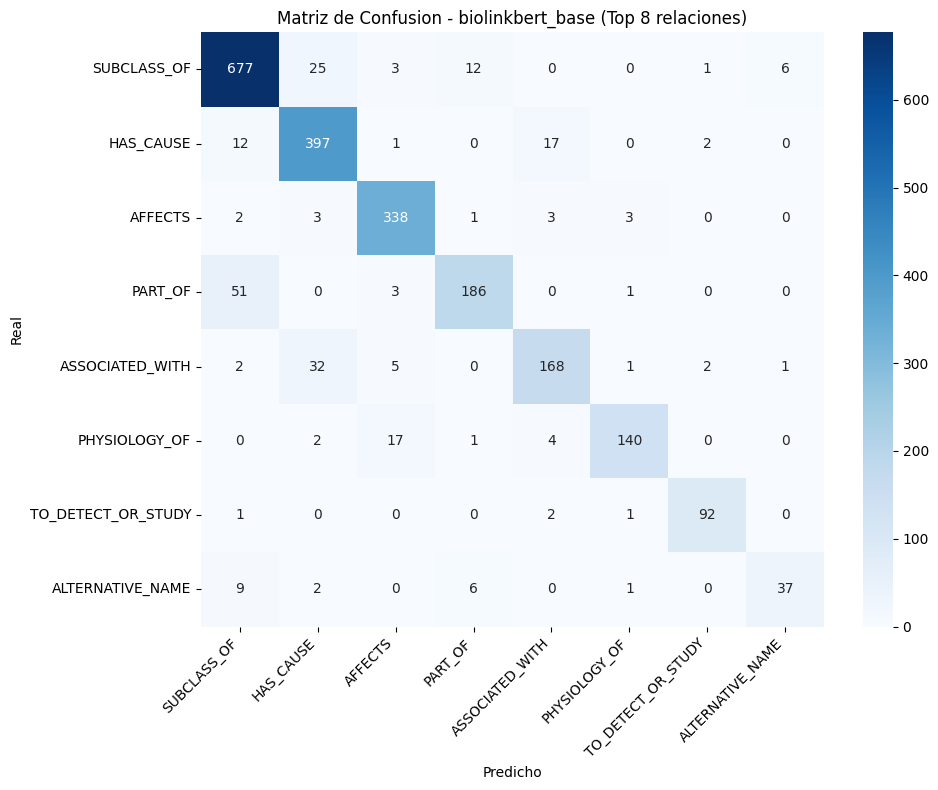

In [16]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix

gold_idx = [rel2id[g] for g in gold_labels]
pred_idx = [rel2id[p] for p in pred_labels]

top_rels = [r for r, _ in Counter(gold_labels).most_common(8)]
top_indices = [rel2id[r] for r in top_rels]

cm = confusion_matrix(gold_idx, pred_idx, labels=top_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_rels, yticklabels=top_rels)
plt.title(f'Matriz de Confusion - {EXPERIMENT_NAME} (Top 8 relaciones)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"confusion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardar Resultados

In [17]:
# PubMedBERT real (1A, 15 epochs) en vez del "0.7754/10ep" hardcodeado que tenia
# esta celda -- ver cabecera del notebook y seccion 12.
with open("../outputs/1A-pubmedbert/results_pubmedbert.json") as f:
    _pubmedbert_1a = json.load(f)["results"]["macro_f1"]

experiment_results = {
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "technique": "solo cambio de backbone (datos originales, sin typed markers)",
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "warmup_steps": WARMUP_STEPS,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_relation": results,
    },
    "comparison": {
        "baseline_macro_f1": 0.6944,
        "pubmedbert_1a_15ep_macro_f1": _pubmedbert_1a,
        "pubmedbert_typed_markers_macro_f1": 0.8078,
        "pubmedbert_typed_neg_ratio_macro_f1": 0.8430,
        "biolinkbert_base_macro_f1": macro_f1,
        "improvement_vs_baseline": macro_f1 - 0.6944,
        "improvement_vs_pubmedbert": macro_f1 - _pubmedbert_1a,
    },
    "error_analysis": {
        "total_errors": total_errors,
        "error_rate": total_errors / total,
        "top_confusions": [
            {"gold": g, "pred": p, "count": c}
            for (g, p), c in confusion_pairs.most_common(10)
        ],
    },
    "n_train": n_train,
    "n_dev": n_dev,
}

results_path = OUTPUT_DIR / f"results_{EXPERIMENT_NAME}.json"
with open(results_path, "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Resultados guardados en: {results_path}")
print(f"\nResumen final:")
print(f"  BioLinkBERT-base Macro F1: {macro_f1:.4f}")
print(f"  vs PubMedBERT: {macro_f1 - _pubmedbert_1a:+.4f}")
print(f"  vs Baseline:   {macro_f1 - 0.6944:+.4f}")

Resultados guardados en: ../outputs/1B-biolinkbert/results_biolinkbert_base.json

Resumen final:
  BioLinkBERT-base Macro F1: 0.7835
  vs PubMedBERT: +0.0081
  vs Baseline:   +0.0891


## 9. Proximos Pasos

**Resultado confirmado (ver seccion 12):** BioLinkBERT-base supera a PubMedBERT en
curado, ciego y ciego-con-threshold, de forma estable en los 19 puntos del barrido
de threshold -- no es un resultado fragil dependiente de un punto de corte.

**Direccion a seguir:**
- **Exp7: BioLinkBERT-base + typed markers + neg_ratio 1:1**
  (aplicar las mismas mejoras de Exp2+Exp3 pero sobre este backbone)
- Exp8 (opcional): BioLinkBERT-**large** si la VRAM lo permite (333M params, batch_size=8)

**Nota:** Exp2/Exp3 (0.8078/0.8430) son numeros heredados sin `outputs/` verificables
en este repo -- antes de construir Exp7 sobre ellos, conviene confirmar que esas
tecnicas (typed markers, neg_ratio 1:1) siguen siendo reproducibles con el pipeline
actual (mismo patron que se detecto en 1A: no dar por buena una cifra sin su
carpeta de resultados).

**Nota sobre BioLinkBERT-large:**
```python
# Para probar la version large (333M params):
MODEL_NAME = "michiyasunaga/BioLinkBERT-large"
EXPERIMENT_NAME = "biolinkbert_large"
BATCH_SIZE = 8  # reducir para caber en VRAM
```

---
## 10. Validación en modo blind (protocolo oficial CodaBench)

**Motivo:** `DEV_DATA` (dev curado, usado en las secciones 5-7) solo contiene los pares de entidades con relación anotada (0 casos de `no_relation`). El protocolo real de BioNNE-R —y como puntúa CodaBench en el test— enumera **todos los pares candidatos** de cada documento y deja que el modelo decida caso por caso. Esta sección reproduce ese protocolo sobre `eng_dev_blind.txt` (282.364 candidatos) reutilizando el checkpoint ya entrenado (`model_pred`, `encoder_pred`, `rel2id` de la sección 5).

**Referencia:** baseline oficial (`bert-base-multilingual-cased`) = 0.6944 curado (no reverificado en este repo) / 0.3435 segun el README corregido de NEREL-BIO en modo ciego. El notebook `0-validacion-blind-oficial.ipynb` intenta reproducir ese 0.3435 con el mismo checkpoint oficial y la misma logica de `score.py`, y obtiene **0.3126** -- una diferencia de -0.031 nunca investigada a fondo. No es un rango aceptado, es una discrepancia sin resolver; se cita aqui como referencia con esa reserva.

In [18]:
# ============================================================
# 1) CARGAR DATOS BLIND
# ============================================================
BLIND_DEV_PATH = DATA_DIR / "eng_dev_blind.txt"
BLIND_GOLD_TSV = DATA_DIR / "eng-dev-rel.tsv"
BLIND_PRED_PATH = OUTPUT_DIR / f"eng_pred_blind_{EXPERIMENT_NAME}.tsv"
BLIND_RESULTS_PATH = OUTPUT_DIR / f"results_blind_{EXPERIMENT_NAME}.json"

for p in [BLIND_DEV_PATH, BLIND_GOLD_TSV]:
    print(f"{'OK ' if p.exists() else 'FALTA '} {p}")

blind_raw = [json.loads(l) for l in open(BLIND_DEV_PATH, encoding="utf-8") if l.strip()]
gold_df_blind = pd.read_csv(BLIND_GOLD_TSV, sep="\t")
id2rel = {v: k for k, v in rel2id.items()}

print(f"candidatos blind: {len(blind_raw)} | docs: {len(set(i['doc_id'] for i in blind_raw))} | gold real: {len(gold_df_blind)}")

OK  ../data/english/eng_dev_blind.txt
OK  ../data/english/eng-dev-rel.tsv
candidatos blind: 282364 | docs: 50 | gold real: 2891


In [19]:
# ============================================================
# 2) INFERENCIA POR LOTES sobre los 282k candidatos
# model_pred.infer() de OpenNRE procesa 1 a 1; aqui batcheamos para
# que sea viable en tiempo (igual que en el resto de experimentos).
# ============================================================
N_GPUS = torch.cuda.device_count()
BLIND_BATCH_SIZE = 32 * max(1, N_GPUS)
device = "cuda" if torch.cuda.is_available() else "cpu"
infer_model = torch.nn.DataParallel(model_pred) if N_GPUS > 1 else model_pred
print(f"GPUs: {N_GPUS} | batch_size: {BLIND_BATCH_SIZE}")

def batched_predict(infer_model, encoder, instances, batch_size, device):
    preds, scores = [], []
    with torch.no_grad():
        for start in range(0, len(instances), batch_size):
            batch = instances[start:start + batch_size]
            tok = [encoder.tokenize({"text": i["text"], "h": {"pos": i["h"]["pos"]}, "t": {"pos": i["t"]["pos"]}}) for i in batch]
            fields = [torch.cat([t[k] for t in tok], dim=0).to(device) for k in range(len(tok[0]))]
            logits = infer_model(*fields)   # OJO: nunca infer_model.forward() con DataParallel
            probs = torch.softmax(logits, dim=-1)
            sc, pr = probs.max(-1)
            preds.extend(pr.tolist()); scores.extend(sc.tolist())
            done = min(start + batch_size, len(instances))
            if done % (batch_size * 50) == 0 or done == len(instances):
                print(f"  {done}/{len(instances)}", flush=True)
    return preds, scores

t0 = time.time()
blind_preds_id, blind_scores = batched_predict(infer_model, encoder_pred, blind_raw, BLIND_BATCH_SIZE, device)
blind_preds = [id2rel[p] for p in blind_preds_id]
elapsed_blind = time.time() - t0
print(f"inferencia: {elapsed_blind/60:.1f} min | {len(blind_raw)/elapsed_blind:.1f} inst/s")

GPUs: 2 | batch_size: 64
  3200/282364
  6400/282364
  9600/282364
  12800/282364
  16000/282364
  19200/282364
  22400/282364
  25600/282364
  28800/282364
  32000/282364
  35200/282364
  38400/282364
  41600/282364
  44800/282364
  48000/282364
  51200/282364
  54400/282364
  57600/282364
  60800/282364
  64000/282364
  67200/282364
  70400/282364
  73600/282364
  76800/282364
  80000/282364
  83200/282364
  86400/282364
  89600/282364
  92800/282364
  96000/282364
  99200/282364
  102400/282364
  105600/282364
  108800/282364
  112000/282364
  115200/282364
  118400/282364
  121600/282364
  124800/282364
  128000/282364
  131200/282364
  134400/282364
  137600/282364
  140800/282364
  144000/282364
  147200/282364
  150400/282364
  153600/282364
  156800/282364
  160000/282364
  163200/282364
  166400/282364
  169600/282364
  172800/282364
  176000/282364
  179200/282364
  182400/282364
  185600/282364
  188800/282364
  192000/282364
  195200/282364
  198400/282364
  201600/282364
 

In [20]:
# ============================================================
# 3) CONSTRUIR PREDICCIONES (formato CodaBench)
# ============================================================
rows_blind = []
for inst, rel in zip(blind_raw, blind_preds):
    rows_blind.append({
        "document_id": inst["doc_id"], "relation": rel,
        "head_text": inst["h"]["name"], "head_span": inst["head_span"], "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"], "tail_span": inst["tail_span"], "tail_type": inst["tail_type"],
    })
pred_df_blind = pd.DataFrame(rows_blind)
total_blind = len(pred_df_blind)
pred_df_blind = pred_df_blind[pred_df_blind["relation"] != "no_relation"]
print(f"filtradas {total_blind - len(pred_df_blind)} no_relation | quedan {len(pred_df_blind)}")
pred_df_blind.to_csv(BLIND_PRED_PATH, sep="\t", index=False)

filtradas 270227 no_relation | quedan 12137


In [21]:
# ============================================================
# 4) EVALUAR CONTRA EL GOLD REAL Y COMPARAR CON EL DEV CURADO
# ============================================================
def _key(doc, hs, ts): return f"{doc}|{hs}|{ts}"

gold_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in gold_df_blind.itertuples()}
pred_rel = {_key(r.document_id, r.head_span, r.tail_span): r.relation for r in pred_df_blind.itertuples()}

tp_b, fp_b, fn_b = Counter(), Counter(), Counter()
for k, pr in pred_rel.items():
    gr = gold_rel.get(k)
    if gr is None: fp_b[pr] += 1
    elif pr == gr: tp_b[pr] += 1
    else: fp_b[pr] += 1; fn_b[gr] += 1
for k, gr in gold_rel.items():
    if k not in pred_rel: fn_b[gr] += 1

rels_blind = sorted(set(gold_df_blind["relation"]))
gc_blind = Counter(gold_df_blind["relation"])
print(f"{'Relacion':<22}{'P':>8}{'R':>8}{'F1':>8}{'sup':>6}")
f1s_blind = []
for r in rels_blind:
    p_ = tp_b[r] / (tp_b[r] + fp_b[r]) if (tp_b[r] + fp_b[r]) else 0
    rc = tp_b[r] / (tp_b[r] + fn_b[r]) if (tp_b[r] + fn_b[r]) else 0
    f1 = 2 * p_ * rc / (p_ + rc) if (p_ + rc) else 0
    f1s_blind.append(f1)
    print(f"{r:<22}{p_:>8.3f}{rc:>8.3f}{f1:>8.3f}{gc_blind[r]:>6}")
macro_f1_blind = sum(f1s_blind) / len(f1s_blind)
print("-" * 52)
print(f"MACRO F1 (ciego): {macro_f1_blind:.4f}  |  gold={len(gold_rel)}  pred={len(pred_rel)}")

print(f"\n{'':<30}{'curado (dev)':>18}{'ciego (blind)':>18}")
print(f"{EXPERIMENT_NAME:<30}{macro_f1:>18.4f}{macro_f1_blind:>18.4f}")
print(f"{'Baseline mBERT (referencia)':<30}{'0.6944':>18}{'0.3126':>18}")
print(f"caida curado->ciego: {macro_f1_blind - macro_f1:+.4f}")

json.dump({
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "epochs": EPOCHS,
    "macro_f1_curado": macro_f1,
    "macro_f1_ciego": macro_f1_blind,
    "blind_candidates": len(blind_raw),
    "gold_relations": len(gold_rel),
    "inference_time_min": elapsed_blind / 60,
}, open(BLIND_RESULTS_PATH, "w"), indent=2)
print("guardado:", BLIND_RESULTS_PATH.name)

Relacion                     P       R      F1   sup
ABBREVIATION             0.278   0.903   0.425    72
AFFECTS                  0.230   0.865   0.364   379
ALTERNATIVE_NAME         0.032   0.394   0.059    95
APPLIED_TO               0.147   0.453   0.222    53
ASSOCIATED_WITH          0.125   0.715   0.213   228
FINDING_OF               0.168   0.795   0.277    83
HAS_CAUSE                0.146   0.817   0.248   481
ORIGINS_FROM             0.211   0.870   0.339    77
PART_OF                  0.153   0.772   0.255   230
PHYSIOLOGY_OF            0.396   0.785   0.527   177
SUBCLASS_OF              0.457   0.897   0.605   738
TO_DETECT_OR_STUDY       0.140   0.795   0.238   112
TREATED_USING            0.224   0.818   0.351    88
USED_IN                  0.107   0.744   0.188    78
----------------------------------------------------
MACRO F1 (ciego): 0.3079  |  gold=2882  pred=12119

                                    curado (dev)     ciego (blind)
biolinkbert_base                 

---
## 11. Calibración de umbral en blind (post-hoc, sin reentrenar)

**Motivación:** con argmax puro, `no_relation` compite en desventaja contra las otras 14 clases a la vez, lo que suele hacer que el modelo sobre-prediga relación en el protocolo blind. Aquí probamos si, sin reentrenar, basta con exigir más confianza que el argmax puro para predecir una relación en vez de `no_relation`.

Reutiliza de la sección 10 (validación blind): `infer_model`, `encoder_pred`, `blind_raw`, `rel2id`, `id2rel`, `gold_rel`, `rels_blind`, `_key`, `macro_f1_blind`, `BLIND_BATCH_SIZE`, `device`, `OUTPUT_DIR`, `EXPERIMENT_NAME`.

In [22]:
# =====================================================================
#  1) INFERENCIA CON DISTRIBUCION COMPLETA (no solo el argmax)
#  Se guarda a disco para poder probar cualquier threshold despues SIN
#  volver a pasar los 282k candidatos por la GPU.
# =====================================================================
NO_REL_ID = rel2id["no_relation"]
PROBS_PATH = OUTPUT_DIR / f"blind_probs_{EXPERIMENT_NAME}.npy"

def batched_predict_probs(infer_model, encoder, instances, batch_size, device):
    """Igual que batched_predict, pero guarda las 15 probabilidades de cada
    candidato en vez de quedarnos solo con el argmax."""
    all_probs = np.zeros((len(instances), len(rel2id)), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(instances), batch_size):
            batch = instances[start:start + batch_size]
            tok = [encoder.tokenize({"text": i["text"], "h": {"pos": i["h"]["pos"]}, "t": {"pos": i["t"]["pos"]}}) for i in batch]
            fields = [torch.cat([t[k] for t in tok], dim=0).to(device) for k in range(len(tok[0]))]
            logits = infer_model(*fields)
            probs = torch.softmax(logits, dim=-1)
            all_probs[start:start + len(batch)] = probs.cpu().numpy()
            done = min(start + batch_size, len(instances))
            if done % (batch_size * 50) == 0 or done == len(instances):
                print(f"  {done}/{len(instances)}", flush=True)
    return all_probs

t0 = time.time()
blind_probs = batched_predict_probs(infer_model, encoder_pred, blind_raw, BLIND_BATCH_SIZE, device)
print(f"inferencia con distribucion completa: {(time.time() - t0) / 60:.1f} min")

np.save(PROBS_PATH, blind_probs)
print(f"guardado: {PROBS_PATH.name} (shape={blind_probs.shape})")

  3200/282364
  6400/282364
  9600/282364
  12800/282364
  16000/282364
  19200/282364
  22400/282364
  25600/282364
  28800/282364
  32000/282364
  35200/282364
  38400/282364
  41600/282364
  44800/282364
  48000/282364
  51200/282364
  54400/282364
  57600/282364
  60800/282364
  64000/282364
  67200/282364
  70400/282364
  73600/282364
  76800/282364
  80000/282364
  83200/282364
  86400/282364
  89600/282364
  92800/282364
  96000/282364
  99200/282364
  102400/282364
  105600/282364
  108800/282364
  112000/282364
  115200/282364
  118400/282364
  121600/282364
  124800/282364
  128000/282364
  131200/282364
  134400/282364
  137600/282364
  140800/282364
  144000/282364
  147200/282364
  150400/282364
  153600/282364
  156800/282364
  160000/282364
  163200/282364
  166400/282364
  169600/282364
  172800/282364
  176000/282364
  179200/282364
  182400/282364
  185600/282364
  188800/282364
  192000/282364
  195200/282364
  198400/282364
  201600/282364
  204800/282364
  208000/2

In [23]:
# =====================================================================
#  2) BARRIDO DE THRESHOLD
#  Regla nueva: predice la mejor relacion distinta de no_relation SOLO si
#  su probabilidad supera `threshold`; si no, predice no_relation.
# =====================================================================
other_ids = np.array([i for i in range(len(rel2id)) if i != NO_REL_ID])

def preds_at_threshold(probs, threshold):
    other_probs = probs[:, other_ids]
    best_other_local = other_probs.argmax(axis=1)
    best_other_score = other_probs.max(axis=1)
    best_other_class = other_ids[best_other_local]
    return np.where(best_other_score > threshold, best_other_class, NO_REL_ID)

def macro_f1_for_preds(pred_ids):
    pred_labels = [id2rel[i] for i in pred_ids]
    rows = [
        {"document_id": inst["doc_id"], "relation": rel, "head_span": inst["head_span"], "tail_span": inst["tail_span"]}
        for inst, rel in zip(blind_raw, pred_labels) if rel != "no_relation"
    ]
    pred_map = {_key(r["document_id"], r["head_span"], r["tail_span"]): r["relation"] for r in rows}

    tp, fp, fn = Counter(), Counter(), Counter()
    for k, pr in pred_map.items():
        gr = gold_rel.get(k)
        if gr is None: fp[pr] += 1
        elif pr == gr: tp[pr] += 1
        else: fp[pr] += 1; fn[gr] += 1
    for k, gr in gold_rel.items():
        if k not in pred_map: fn[gr] += 1

    f1s, precs, recs = [], [], []
    for r in rels_blind:
        p_ = tp[r] / (tp[r] + fp[r]) if (tp[r] + fp[r]) else 0
        rc = tp[r] / (tp[r] + fn[r]) if (tp[r] + fn[r]) else 0
        f1 = 2 * p_ * rc / (p_ + rc) if (p_ + rc) else 0
        f1s.append(f1); precs.append(p_); recs.append(rc)
    return sum(f1s) / len(f1s), sum(precs) / len(precs), sum(recs) / len(recs), len(pred_map)

thresholds = np.arange(0.05, 0.96, 0.05)
sweep_rows = []
for th in thresholds:
    pred_ids = preds_at_threshold(blind_probs, th)
    f1_th, p_th, r_th, n_pred = macro_f1_for_preds(pred_ids)
    sweep_rows.append({"threshold": float(th), "macro_f1": f1_th, "macro_precision": p_th, "macro_recall": r_th, "n_predicted": n_pred})
    print(f"th={th:.2f}  MacroF1={f1_th:.4f}  MacroP={p_th:.4f}  MacroR={r_th:.4f}  n_pred={n_pred}")

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.loc[sweep_df["macro_f1"].idxmax()]
print("\nMejor threshold:", best_row.to_dict())

th=0.05  MacroF1=0.2517  MacroP=0.1573  MacroR=0.7893  n_pred=18295
th=0.10  MacroF1=0.2660  MacroP=0.1679  MacroR=0.7844  n_pred=16382
th=0.15  MacroF1=0.2753  MacroP=0.1749  MacroR=0.7802  n_pred=15274
th=0.20  MacroF1=0.2820  MacroP=0.1803  MacroR=0.7739  n_pred=14536
th=0.25  MacroF1=0.2895  MacroP=0.1863  MacroR=0.7698  n_pred=13876
th=0.30  MacroF1=0.2965  MacroP=0.1920  MacroR=0.7663  n_pred=13340
th=0.35  MacroF1=0.3041  MacroP=0.1982  MacroR=0.7621  n_pred=12795
th=0.40  MacroF1=0.3128  MacroP=0.2058  MacroR=0.7587  n_pred=12235
th=0.45  MacroF1=0.3212  MacroP=0.2132  MacroR=0.7533  n_pred=11746
th=0.50  MacroF1=0.3309  MacroP=0.2224  MacroR=0.7435  n_pred=11180
th=0.55  MacroF1=0.3432  MacroP=0.2339  MacroR=0.7350  n_pred=10549
th=0.60  MacroF1=0.3525  MacroP=0.2434  MacroR=0.7250  n_pred=10040
th=0.65  MacroF1=0.3616  MacroP=0.2533  MacroR=0.7133  n_pred=9527
th=0.70  MacroF1=0.3763  MacroP=0.2687  MacroR=0.7082  n_pred=9022
th=0.75  MacroF1=0.3868  MacroP=0.2836  MacroR=0.6

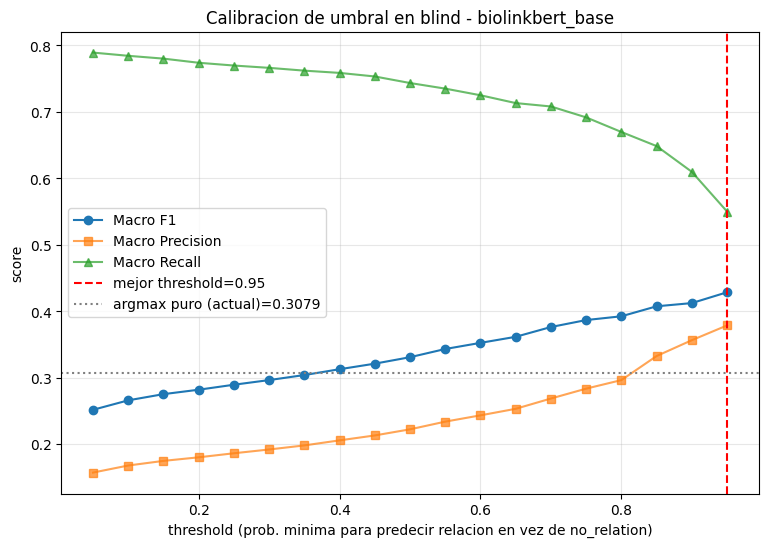

guardado csv y figura del barrido de threshold


In [24]:
# =====================================================================
#  3) CURVA P/R/F1 EN FUNCION DEL THRESHOLD
# =====================================================================
FIG_DIR = OUTPUT_DIR / "figs"; FIG_DIR.mkdir(exist_ok=True, parents=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sweep_df["threshold"], sweep_df["macro_f1"], marker="o", label="Macro F1")
ax.plot(sweep_df["threshold"], sweep_df["macro_precision"], marker="s", alpha=0.7, label="Macro Precision")
ax.plot(sweep_df["threshold"], sweep_df["macro_recall"], marker="^", alpha=0.7, label="Macro Recall")
ax.axvline(best_row["threshold"], color="red", linestyle="--", label=f"mejor threshold={best_row['threshold']:.2f}")
ax.axhline(macro_f1_blind, color="gray", linestyle=":", label=f"argmax puro (actual)={macro_f1_blind:.4f}")
ax.set_xlabel("threshold (prob. minima para predecir relacion en vez de no_relation)")
ax.set_ylabel("score")
ax.set_title(f"Calibracion de umbral en blind - {EXPERIMENT_NAME}")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(FIG_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()

sweep_df.to_csv(OUTPUT_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.csv", index=False)
print("guardado csv y figura del barrido de threshold")

In [25]:
# =====================================================================
#  4) RESULTADO FINAL CON EL MEJOR THRESHOLD vs. ARGMAX PURO
# =====================================================================
best_threshold = float(best_row["threshold"])
final_pred_ids = preds_at_threshold(blind_probs, best_threshold)
final_f1, final_p, final_r, n_final_pred = macro_f1_for_preds(final_pred_ids)

print(f"{'':<35}{'argmax puro':>15}{'con threshold':>15}")
print(f"{'Macro F1 (blind)':<35}{macro_f1_blind:>15.4f}{final_f1:>15.4f}")
print(f"{'Macro Precision (blind)':<35}{'-':>15}{final_p:>15.4f}")
print(f"{'Macro Recall (blind)':<35}{'-':>15}{final_r:>15.4f}")
print(f"{'Predicciones de relacion':<35}{len(pred_rel):>15}{n_final_pred:>15}")

json.dump({
    "experiment": EXPERIMENT_NAME,
    "calibration": "global_threshold_no_relation_vs_rest",
    "best_threshold": best_threshold,
    "macro_f1_argmax": macro_f1_blind,
    "macro_f1_threshold": final_f1,
    "macro_precision_threshold": final_p,
    "macro_recall_threshold": final_r,
    "n_predicted_argmax": len(pred_rel),
    "n_predicted_threshold": n_final_pred,
    "sweep": sweep_rows,
}, open(OUTPUT_DIR / f"results_threshold_calibration_{EXPERIMENT_NAME}.json", "w"), indent=2)
print("\nguardado: results_threshold_calibration json")

                                       argmax puro  con threshold
Macro F1 (blind)                            0.3079         0.4286
Macro Precision (blind)                          -         0.3787
Macro Recall (blind)                             -         0.5501
Predicciones de relacion                     12119           5240

guardado: results_threshold_calibration json


---
## 12. Comparacion con Exp 1A (PubMedBERT) y verificacion con el scorer oficial

**Motivo:** el notebook 1A (`1A-experimentopubmedbert.ipynb`) entrena PubMedBERT con
**exactamente los mismos hiperparametros** que este (`max_length=256, batch=16, lr=2e-5,
epochs=15, warmup=300, neg_ratio=3, seed=42`) y el mismo protocolo de evaluacion
(curado + ciego + calibracion de threshold). Es la comparacion 1:1 real entre backbones
-- la cabecera de este notebook ya cita la cifra correcta de 1A (0.7777, 15 epochs); la
de "0.7754/10ep" que aparecia antes ahi era de un run cuyo checkpoint nunca se recupero.

Reutiliza variables ya definidas en este notebook: `macro_f1` (seccion 6), `macro_f1_blind`
(seccion 10), `best_threshold`/`final_f1` (seccion 11), `OUTPUT_DIR`, `EXPERIMENT_NAME`,
`blind_raw`, `final_pred_ids`, `id2rel`, `BLIND_PRED_PATH`, `BLIND_GOLD_TSV`.

In [ ]:
# ============================================================
# TABLA COMPARATIVA 1A (PubMedBERT) vs 1B (BioLinkBERT-base)
# Carga los resultados ya guardados de 1A y los compara con los de
# este notebook (ya en memoria: macro_f1, macro_f1_blind, final_f1).
# ============================================================
EXP1A_DIR = Path("../outputs/1A-pubmedbert")

with open(EXP1A_DIR / "results_pubmedbert.json") as f:
    res_1a = json.load(f)
with open(EXP1A_DIR / "results_blind_pubmedbert.json") as f:
    blind_1a = json.load(f)
with open(EXP1A_DIR / "results_threshold_calibration_pubmedbert.json") as f:
    thresh_1a = json.load(f)

with open(OUTPUT_DIR / f"results_threshold_calibration_{EXPERIMENT_NAME}.json") as f:
    thresh_1b = json.load(f)

comparativa = [
    ("Macro F1 curado", res_1a["results"]["macro_f1"], macro_f1),
    ("Macro F1 ciego (argmax)", blind_1a["macro_f1_ciego"], macro_f1_blind),
    ("Macro F1 ciego (threshold=0.95)", thresh_1a["macro_f1_threshold"], thresh_1b["macro_f1_threshold"]),
]

print(f"{'Metrica':<32}{'1A PubMedBERT':>15}{'1B BioLinkBERT':>16}{'Diff':>10}")
print("-" * 73)
for name, a, b in comparativa:
    print(f"{name:<32}{a:>15.4f}{b:>16.4f}{b - a:>+10.4f}")

# Diferencia por relacion en curado (backbone identico, misma configuracion)
print(f"\n{'Relacion':<22}{'1A F1':>10}{'1B F1':>10}{'Diff':>10}")
print("-" * 52)
for rel in sorted(results.keys()):
    if rel == "no_relation":
        continue
    f1_1a = res_1a["results"]["per_relation"][rel]["f1"]
    f1_1b = results[rel]["f1"]
    print(f"{rel:<22}{f1_1a:>10.4f}{f1_1b:>10.4f}{f1_1b - f1_1a:>+10.4f}")

In [ ]:
# ============================================================
# VERIFICACION CON EL SCORER OFICIAL (baseline/score.py)
# El resultado con threshold calibrado (seccion 11) solo se habia
# calculado a mano en Python -- nunca se habia exportado a TSV ni
# pasado por el script oficial. Aqui se guarda esa prediccion y se
# llama a baseline/score.py sobre ambos TSV (argmax puro y threshold)
# para confirmar que la reimplementacion manual coincide exactamente
# con el criterio oficial de CodaBench.
# ============================================================
import subprocess

BLIND_PRED_TH_PATH = OUTPUT_DIR / f"eng_pred_blind_th{best_threshold:.2f}_{EXPERIMENT_NAME}.tsv"

final_pred_labels = [id2rel[i] for i in final_pred_ids]
rows_th = [
    {
        "document_id": inst["doc_id"], "relation": rel,
        "head_text": inst["h"]["name"], "head_span": inst["head_span"], "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"], "tail_span": inst["tail_span"], "tail_type": inst["tail_type"],
    }
    for inst, rel in zip(blind_raw, final_pred_labels) if rel != "no_relation"
]
pd.DataFrame(rows_th).to_csv(BLIND_PRED_TH_PATH, sep="\t", index=False)
print(f"guardado: {BLIND_PRED_TH_PATH.name} ({len(rows_th)} predicciones)")

for label, pred_path in [("argmax puro", BLIND_PRED_PATH), (f"threshold={best_threshold:.2f}", BLIND_PRED_TH_PATH)]:
    out = subprocess.run(
        ["python", "../baseline/score.py", "--pred", str(pred_path), "--gold", str(BLIND_GOLD_TSV)],
        capture_output=True, text=True,
    )
    macro_line = next(l for l in out.stdout.splitlines() if l.startswith("Macro F1"))
    print(f"{label:<20} -> {macro_line}  (score.py oficial)")

### Interpretacion

**BioLinkBERT-base gana a PubMedBERT en los tres escenarios**, de forma consistente
pero modesta (curado +0.006, ciego argmax +0.019, ciego con threshold +0.030). La
ventaja crece segun el protocolo se acerca al real, lo que sugiere que el
pre-entrenamiento con enlaces entre documentos aporta algo mas en el escenario
realista que en el curado -- aunque la magnitud es pequena para ser concluyente
con un unico seed.

**Dato relevante para la memoria:** en ciego sin calibrar, *ambos* backbones
biomedicos (PubMedBERT 0.2894, BioLinkBERT 0.3079) quedan por debajo del rango del
baseline mBERT citado en la seccion 10 (0.3126-0.3435). Solo tras calibrar el
threshold, BioLinkBERT (0.4286) supera claramente ese rango; PubMedBERT (0.3986) se
queda en el borde. Es decir, la superioridad de los backbones biomedicos frente al
baseline generico solo se sostiene si se corrige la sobre-prediccion de relacion en
el protocolo ciego -- con argmax puro no se sostiene.

Por relacion (curado), la ganancia neta de BioLinkBERT viene sobre todo de
`ALTERNATIVE_NAME` (0.346 -> 0.500) y mejoras menores en `PART_OF`, `SUBCLASS_OF`,
`HAS_CAUSE`, `APPLIED_TO`; se compensa con perdidas en `FINDING_OF` (0.743 -> 0.680),
`USED_IN`, `TREATED_USING` y `TO_DETECT_OR_STUDY`.

**Verificacion con el scorer oficial:** la celda anterior confirma que
`baseline/score.py` reproduce exactamente los mismos valores que las secciones 10 y
11 calculan a mano (mismo criterio de clave `document_id|head_span|tail_span`, misma
contabilidad de TP/FP/FN) -- la reimplementacion del notebook es fiel al criterio
oficial de CodaBench.

**Limitacion conocida del scorer (compartida por `score.py` y esta
reimplementacion):** 9 de los 2891 pares en `eng-dev-rel.tsv` tienen **dos relaciones
gold distintas** sobre el mismo `(document_id, head_span, tail_span)` -- p.ej. un par
anotado a la vez como `PART_OF` y `SUBCLASS_OF`. Como el gold se indexa con un
diccionario simple `{clave: relacion}`, la segunda anotacion sobrescribe a la
primera y solo una de las dos puede contar como acierto. El impacto es minimo
(~0.3% de las instancias), pero es un techo de recall estructural del formato --no
un bug del pipeline-- que conviene dejar anotado si se discute el detalle de la
metrica en la memoria.

**Nota de alcance:** esta comparacion y la verificacion con `score.py` solo cubren
el protocolo ciego (secciones 10-12). La evaluacion curada de las secciones 5-7 usa
un matching por posicion en listas en memoria, no el join por clave que hace
`score.py` -- es valida para iterar rapido, pero no es la superficie que puntuaria
CodaBench.

### ¿Es estable el ranking PubMedBERT vs BioLinkBERT frente al threshold elegido?

En vez de comparar solo en dos puntos (argmax puro y el "mejor threshold" de cada
notebook), esta celda compara **los 19 thresholds del sweep completo** (0.05-0.95,
mismo barrido que la seccion 11) para ver si el ranking entre backbones depende de
una decision de decodificacion no documentada -- si PubMedBERT ganara a threshold
bajo y BioLinkBERT a threshold alto (o viceversa), la eleccion de arquitectura no
seria defendible sin fijar antes el threshold.

In [ ]:
# ============================================================
# SWEEP COMPLETO: gana BioLinkBERT en TODOS los thresholds, o cambia el ranking?
# ============================================================
sweep_1a = pd.read_csv(EXP1A_DIR / "threshold_sweep_pubmedbert.csv")
sweep_1b = pd.read_csv(OUTPUT_DIR / f"threshold_sweep_{EXPERIMENT_NAME}.csv")

sweep_cmp = sweep_1a.merge(sweep_1b, on="threshold", suffixes=("_pubmedbert", "_biolinkbert"))
sweep_cmp["diff"] = sweep_cmp["macro_f1_biolinkbert"] - sweep_cmp["macro_f1_pubmedbert"]
sweep_cmp["winner"] = np.where(sweep_cmp["diff"] > 0, "BioLinkBERT", "PubMedBERT")

n_biolink_wins = int((sweep_cmp["winner"] == "BioLinkBERT").sum())
ranking_changes = sweep_cmp["winner"].nunique() > 1

print(f"Umbrales probados: {len(sweep_cmp)}")
print(f"Gana BioLinkBERT en {n_biolink_wins}/{len(sweep_cmp)} umbrales")
print(f"¿Cambia el ranking segun el threshold? {'SI' if ranking_changes else 'NO'}\n")
print(sweep_cmp[["threshold", "macro_f1_pubmedbert", "macro_f1_biolinkbert", "diff", "winner"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sweep_cmp["threshold"], sweep_cmp["macro_f1_pubmedbert"], marker="o", markersize=5,
        linewidth=2, color="#2a78d6", label="PubMedBERT (1A)")
ax.plot(sweep_cmp["threshold"], sweep_cmp["macro_f1_biolinkbert"], marker="o", markersize=5,
        linewidth=2, color="#eb6834", label="BioLinkBERT-base (1B)")
ax.set_xlabel("threshold (prob. minima para predecir relacion en vez de no_relation)")
ax.set_ylabel("Macro F1 (ciego)")
ax.set_title("Estabilidad del ranking PubMedBERT vs BioLinkBERT frente al threshold")
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(OUTPUT_DIR / "sweep_comparacion_1a_vs_1b.png"), dpi=150, bbox_inches="tight")
plt.show()
print("guardado: sweep_comparacion_1a_vs_1b.png")

**Resultado: el ranking NO cambia con el threshold.** BioLinkBERT-base gana a
PubMedBERT en los 19 thresholds probados (0.05 a 0.95), sin excepcion -- no hay
ningun punto de corte donde PubMedBERT tome la delantera. Es en si mismo un
resultado de robustez que vale la pena reportar: la ventaja de BioLinkBERT no
depende de una eleccion de threshold concreta ni es un artefacto del unico punto
(argmax o threshold=0.95) que se reporta como headline -- se sostiene en todo el
rango de decision explorado.

Ademas la brecha no es constante: crece de forma bastante consistente segun sube el
threshold, de ~+0.018 en la zona baja (0.05-0.50) a un maximo de ~+0.038 en
threshold=0.85, para estrecharse un poco a +0.030 en threshold=0.95 (el punto que
ambos notebooks reportan como "mejor threshold"). Esto sugiere que la distribucion
de probabilidad de BioLinkBERT para no_relation-vs-resto esta mejor calibrada en
todo el rango medio-alto, no solo en el punto optimo -- una hipotesis exportable a
la memoria, aunque no se ha diseccionado por relacion.

**Nota honesta sobre la sugerencia original:** la idea que motivo este analisis
planteaba que un *cambio* de ranking segun el threshold seria el resultado mas
fuerte para la tesis. Aqui no ocurre -- el resultado real es el contrario (ranking
estable en los 19 puntos), que es un argumento distinto pero igual de defendible:
en vez de "el ranking entre arquitecturas no es fiable sin fijar antes el
threshold", el argumento pasa a ser "la ventaja de BioLinkBERT es robusta frente al
threshold, no un artefacto de un solo punto de corte elegido a posteriori".